# Step 1: Setup prerequisites

- Set the LLM provider and passkey provided by your workshop instructor

- `LLM_PROVIDER` can be set to one of "aws"/ "microsoft" / "google"

In [ ]:
# NOTE: LLM_PROVIDER can be set to one of "aws"/ "microsoft" / "google"
LLM_PROVIDER = "aws"
PASSKEY = "replace-with-passkey"

In [2]:
import os
import sys
from pymongo import MongoClient

# Add parent directory to path to import from utils
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
from utils import set_env

# ----- MONGODB SETUP -----
# If you are using your own MongoDB Atlas cluster, use the connection string for your cluster here
MONGODB_URI = os.environ.get("MONGODB_URI")
# Initialize a MongoDB Python client
mongodb_client = MongoClient(MONGODB_URI, appname="devrel-workshop-ai-agents")
# Check the connection to the server
mongodb_client.admin.command("ping")

# ----- API KEY SETUP -----
# Obtain API keys from our AI model proxy and set them as environment variables-- DO NOT CHANGE
set_env([LLM_PROVIDER, "voyageai"], PASSKEY)

Successfully set AWS_ACCESS_KEY_ID environment variable.
Successfully set AWS_SECRET_ACCESS_KEY environment variable.
Successfully set VOYAGE_API_KEY environment variable.


# Step 2: Import data into MongoDB

In [48]:
import json

### **Do not change the values assigned to the variables below**

In [49]:
#  Database name
DB_NAME = "mongodb_genai_devday_agents"
# Name of the collection to store flights data
FLIGHTS_COLLECTION_NAME = "flights"
# Name of the collection to store AirBnB listings data
LISTINGS_COLLECTION_NAME = "listings"
# Name of the collection to store bookings data
BOOKINGS_COLLECTION_NAME = "bookings"


In [50]:
# Connect to the `LISTINGS_COLLECTION_NAME` collection.
listings_collection = mongodb_client[DB_NAME][LISTINGS_COLLECTION_NAME]
# Connect to the `FLIGHTS_COLLECTION_NAME` collection.
flights_collection = mongodb_client[DB_NAME][FLIGHTS_COLLECTION_NAME]
# Connect to the `BOOKINGS_COLLECTION_NAME` collection.
bookings_collection = mongodb_client[DB_NAME][BOOKINGS_COLLECTION_NAME]


In [ ]:
# Insert a dataset of AirBnB listings into the `LISTINGS_COLLECTION_NAME` collection
with open(f"../data/{LISTINGS_COLLECTION_NAME}.json", "r") as data_file:
    json_data = data_file.read()

data = json.loads(json_data)

print(f"Deleting existing documents from the {LISTINGS_COLLECTION_NAME} collection.")
listings_collection.delete_many({})
listings_collection.insert_many(data)
print(
    f"{listings_collection.count_documents({})} documents ingested into the {LISTINGS_COLLECTION_NAME} collection."
)

Deleting existing documents from the listings collection.
200 documents ingested into the listings collection.


In [26]:
# Insert a dataset of flight routes into the `FLIGHTS_COLLECTION_NAME` collection
with open(f"../data/{FLIGHTS_COLLECTION_NAME}.json", "r") as data_file:
    json_data = data_file.read()

data = json.loads(json_data)

print(f"Deleting existing documents from the {FLIGHTS_COLLECTION_NAME} collection.")
flights_collection.delete_many({})
flights_collection.insert_many(data)
print(
    f"{flights_collection.count_documents({})} documents ingested into the {FLIGHTS_COLLECTION_NAME} collection."
)

Deleting existing documents from the flights collection.
358 documents ingested into the flights collection.


# Step 3: Instantiate the LLM

In [12]:
from utils import get_llm

In [13]:
# Obtain the Langchain LLM object using the `get_llm` function from the `utils`` module.
llm = get_llm(LLM_PROVIDER)

# Step 4: Build the agent's toolbox


In [14]:
from langchain_mongodb.agent_toolkit.database import MongoDBDatabase
from langchain_mongodb.agent_toolkit.toolkit import MongoDBDatabaseToolkit

In [38]:
# Access the `sample_mflix` database using the `MongoDBDatabase` class
db = MongoDBDatabase.from_connection_string(connection_string=MONGODB_URI, database=DB_NAME)

In [73]:
toolkit = MongoDBDatabaseToolkit(db=db, llm=llm)

### Create a custom tool

In [130]:
from datetime import datetime, timezone
from typing import Literal
from langchain.tools import tool

In [ ]:
@tool
def create_booking(
    booking_type: Literal["flight", "accommodation"],
    traveler_name: str,
    destination: str,
    item_name: str,
    price_usd: float,
    travelers: int = 1,
) -> str:
    """Save booking details to the bookings collection.

    Args:
        booking_type: Either "flight" or "accommodation".
        traveler_name: Full name of the traveler making the booking.
        destination: Destination city, e.g. "Barcelona".
        item_name: Flight number for flights, or listing name for accommodation.
        price_usd: Total price of this booking in USD.
        travelers: Number of travelers. Defaults to 1.
    """
    booking = {
        "booking_type": booking_type,
        "traveler_name": traveler_name,
        "destination": destination,
        "item_name": item_name,
        "price_usd": price_usd,
        "travelers": travelers,
        "created_at": datetime.now(timezone.utc),
    }
    bookings_collection.insert_one(booking)
    return f"Booked {booking_type} to {destination}: {item_name}. Total price ${price_usd:.2f} for {travelers} travelers."

### Investigate the tools

In [180]:
## Get the list of tools from the MongoDB database toolkit
tools = toolkit.get_tools()
# Append the `create_booking` tool to the set of tools obtained from the MongoDB database toolkit
tools.append(create_booking)

In [ ]:
# Investigate the tool names, descriptions and arguments for each tool
tools_map = {t.name: t for t in tools}

for name, tool in tools_map.items():
    print(f"{name}\n  description: {tool.description}\n  args: {tool.args}\n")

mongodb_query
  description: Input to this tool is a detailed and correct MongoDB query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use mongodb_schema to query the correct collections fields.
  args: {'query': {'description': 'A detailed and correct MongoDB query.', 'title': 'Query', 'type': 'string'}}

mongodb_schema
  description: Input to this tool is a comma-separated list of collections, output is the schema and sample rows for those collections. Be sure that the collectionss actually exist by calling mongodb_list_collections first! Example Input: collection1, collection2, collection3
  args: {'collection_names': {'description': "A comma-separated list of the collection names for which to return the schema. Example input: 'collection1, collection2, collection3'", 'title': 'Collec

### Test the tools


In [19]:
# Test out the `mongodb_list_collections` tool
tools_map["mongodb_list_collections"].invoke("")

'flights, listings'

In [54]:
# Test out the `mongodb_schema` tool 
print(tools_map["mongodb_schema"].invoke("listings"))

Database name: mongodb_genai_devday_agents
Collection name: listings
Schema from a sample of documents from the collection:
_id: String
listing_url: String
name: String
summary: String
space: String
description: String
neighborhood_overview: String
notes: String
transit: String
access: String
interaction: String
house_rules: String
property_type: String
room_type: String
bed_type: String
minimum_nights: Number
maximum_nights: Number
cancellation_policy: String
accommodates: Number
bedrooms: Number
beds: Number
number_of_reviews: Number
bathrooms: Number
amenities: Array<String>
price: Number
security_deposit: Number
cleaning_fee: Number
extra_people: Number
guests_included: Number
images.thumbnail_url: String
images.medium_url: String
images.picture_url: String
images.xl_picture_url: String
host.host_id: String
host.host_url: String
host.host_name: String
host.host_location: String
host.host_about: String
host.host_response_time: String
host.host_thumbnail_url: String
host.host_picture

In [21]:
# Test the `mongodb_query_checker` tool
query = 'db.flights.aggregate([{"$match": {"to_city": "Barcelona",}}, {"$limit": 3}])'
tools_map["mongodb_query_checker"].invoke(query)

AIMessage(content='Here is the corrected MongoDB query:\n\n```\ndb.flights.aggregate([{"$match": {"to_city": "Barcelona"}}, {"$limit": 3}])\n```\n\nThe trailing comma after `"Barcelona"` was removed as it is not valid JSON.', additional_kwargs={'usage': {'prompt_tokens': 133, 'completion_tokens': 62, 'cache_read_input_tokens': 0, 'cache_write_input_tokens': 0, 'total_tokens': 195}, 'stop_reason': 'end_turn', 'model_id': 'global.anthropic.claude-sonnet-4-6'}, response_metadata={'usage': {'prompt_tokens': 133, 'completion_tokens': 62, 'cache_read_input_tokens': 0, 'cache_write_input_tokens': 0, 'total_tokens': 195}, 'stop_reason': 'end_turn', 'model_id': 'global.anthropic.claude-sonnet-4-6', 'model_provider': 'bedrock', 'model_name': 'global.anthropic.claude-sonnet-4-6'}, id='lc_run--01a0402c-12fa-7d02-a381-b583d282b7d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 133, 'output_tokens': 62, 'total_tokens': 195, 'input_token_details': {'cache_creation': 0, 'cac

In [22]:
# Test the `mongodb_query` tool
query = [
    {"$match": {"to_city": "Barcelona"}},
    {"$limit": 3}
]
print(tools_map["mongodb_query"].invoke(f"db.flights.aggregate({json.dumps(query)})"))

[
  {
    "_id": "6a754290252087059f208b40",
    "flight_number": "AF512",
    "airline": "Air France",
    "from_airport": "CDG",
    "from_city": "Paris",
    "from_country": "FR",
    "to_airport": "BCN",
    "to_city": "Barcelona",
    "to_country": "ES",
    "duration_minutes": 97,
    "stops": 0,
    "price_usd": 120.38
  },
  {
    "_id": "f96919a3f17c4e0d68bcba6f",
    "flight_number": "FO305",
    "airline": "Formosa Airlines",
    "from_airport": "CDG",
    "from_city": "Paris",
    "from_country": "FR",
    "to_airport": "BCN",
    "to_city": "Barcelona",
    "to_country": "ES",
    "duration_minutes": 97,
    "stops": 0,
    "price_usd": 167.2
  },
  {
    "_id": "f81e51fdd84336994c9825aa",
    "flight_number": "IB896",
    "airline": "Iberia Airlines",
    "from_airport": "CDG",
    "from_city": "Paris",
    "from_country": "FR",
    "to_airport": "BCN",
    "to_city": "Barcelona",
    "to_country": "ES",
    "duration_minutes": 97,
    "stops": 0,
    "price_usd": 152.38


In [53]:
# Test the `create_booking` tool
create_booking.invoke({
    "booking_type": "flight",
    "traveler_name": "Sam Rivera",
    "destination": "Barcelona",
    "item_name": "TA303",
    "price_usd": 230.96,
    "travelers": 2
})

'Booked flight to Barcelona: TA303, Total price $230.96 for 2 travelers.'

# Step 5: Create the LLM prompt

In addition to the tools, the MongoDB database toolkit also provides an LLM system prompt containing guidance on how to use the tools available in the toolkit. However, we will create our own system prompt since we want to provide additional tools and instructions to the agent.

You can access the system prompt available in the toolkit as follows:
```
from langchain_mongodb.agent_toolkit import MONGODB_AGENT_SYSTEM_PROMPT
```

In [58]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [87]:
SYSTEM_PROMPT = """
You are an agent designed to interact with a MongoDB database. 
You have access to the following tools: {tool_names}.
Only use the information returned by the tools to construct your final answer.

Most tools are read-only, but you can perform write actions to create new bookings and store them to MongoDB using the `create_booking` tool.

ALWAYS start by looking at the collections in the database to see what you can query, unless you have this information in memory.
Then you should query the schema of the most relevant collections.
To get data from MongoDB, create a syntactically correct MongoDB query to run, analyze the results of the query and decide what to do next.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant field to return the most interesting examples in the database.
Never query for all the fields from a specific collection, only query for the relevant fields given the question.
Read queries MUST include the collection name and the contents of the aggregation pipeline. An example query looks like:

```python
db.flights.aggregate([{{"\$match": {{"to_city": "Barcelona"}}}}, {{"\$limit": 3}}])
```

Do not re-run tools unless absolutely necessary. If you are not able to get enough information using the tools, reply with I DON'T KNOW.
"""

In [88]:
# Create a templated prompt for the LLM
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT),
        MessagesPlaceholder(variable_name="messages")
    ]
)

In [89]:
# Pre-fill `top_k` and `tool_names` in the prompt template
prompt = prompt.partial(top_k=5, tool_names=", ".join([tool.name for tool in tools]))

# Step 6: Give the LLM access to tools

📚 https://docs.langchain.com/oss/python/langgraph/quickstart#1-define-tools-and-model

In [90]:
# Bind the `tools` to the `llm` instantiated in Step 4
bind_tools = llm.bind_tools(tools)

📚 https://reference.langchain.com/python/langchain-core/runnables/base/Runnable/pipe (See Example)

In [91]:
# Chain the `prompt` with the tool-augmented_llm using the `|` operator
llm_with_tools = prompt | bind_tools

In [ ]:
# Test that the LLM is making the right tool calls
llm_with_tools.invoke(
    ["I want to go to Barcelona. What's the cheapest nonstop flight there?"]
).tool_calls

[{'name': 'mongodb_list_collections',
  'args': {},
  'id': 'toolu_bdrk_01LwGDBpZNMzKSBWSmvKdjUX',
  'type': 'tool_call'}]

The above test shows that the LLM will first call the `mongodb_list_collections` tool, given any query.

This is exactly what we want the agent to do as the first step so it can better understand our data.

# Step 7: Define graph state

In [93]:
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

In [94]:
# Define the graph state
# We are only tracking chat messages but you can track other attributes as well
class GraphState(TypedDict):
    messages: Annotated[list, add_messages]

# Step 7: Define graph nodes

In [97]:
from langchain_core.messages import ToolMessage
from typing import Dict, List
from pprint import pprint

In [ ]:
# Define the agent node
def agent_node(state: GraphState) -> Dict[str, List]:
    """
    Agent node

    Args:
        state (GraphState): Graph state

    Returns:
        Dict[str, List]: Updates to messages
    """
    # Get the messages from the graph `state`
    messages = state["messages"]
    # Invoke `llm_with_tools` with `messages` using the `invoke` method
    # HINT: See Step 6 for how to invoke `llm_with_tools`
    result = llm_with_tools.invoke(messages)
    # Write `result` to the `messages` attribute of the graph state
    return {"messages": [result]}

In [101]:
# Define tool node
def tool_node(state: GraphState) -> Dict[str, List]:
    """
    Tool node

    Args:
        state (GraphState): Graph state

    Returns:
        Dict[str, List]: Updates to messages
    """
    result = []
    # Get the list of tool calls from messages
    tool_calls = state["messages"][-1].tool_calls
    # A tool_call looks as follows:
    # {
    #     "name": "get_information_for_question_answering",
    #     "args": {"user_query": "What are Atlas Triggers"},
    #     "id": "call_H5TttXb423JfoulF1qVfPN3m",
    #     "type": "tool_call",
    # }
    # Iterate through `tool_calls`
    for tool_call in tool_calls:
        # Get the tool from `tools_map` defined in Step 4, using the `name` attribute of the `tool_call`
        tool = tools_map[tool_call["name"]]
        # Invoke the `tool` using the `args` attribute of the `tool_call`
        # HINT: See previous line to see how to extract attributes from `tool_call`
        observation = tool.invoke(tool_call["args"])
        # Append the result of executing the tool to the `result` list as a ToolMessage
        # The `content` of the message is `observation` i.e. result of the tool call
        # The `tool_call_id` can be obtained from the `tool_call`
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    # Write `result` to the `messages` attribute of the graph state
    return {"messages": result}

# Step 8: Define conditional edges

In [102]:
from langgraph.graph import END

In [103]:
# Define conditional routing function
def route_tools(state: GraphState):
    """
    Use in the conditional_edge to route to the tool node if the last message
    has tool calls. Otherwise, route to the end.
    """
    # Get messages from graph state
    messages = state.get("messages", [])
    if len(messages) > 0:
        # Get the last AI message from messages
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    # Check if the last message has tool calls
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        # If yes, return "tools"
        return "tools"
    # If no, return END
    return END

# Step 9: Build the graph

In [104]:
from langgraph.graph import StateGraph, START

In [105]:
# Instantiate the graph
graph = StateGraph(GraphState)

📚 https://docs.langchain.com/oss/python/langgraph/graph-api#nodes

In [ ]:
# Add nodes to the `graph` using the `add_node` function
# Add a `agent` node. The `agent` node should run the `agent` function
graph.add_node("agent", agent_node)
# Add a `tools` node. The `tools` node should run the `tool_node` function
graph.add_node("tools", tool_node)

📚 https://docs.langchain.com/oss/python/langgraph/graph-api#normal-edges

In [107]:
# Add fixed edges to the `graph` using the `add_edge` method
# Add an edge from the START node to the `agent` node
graph.add_edge(START, "agent")
# Add an edge from the `tools` node to the `agent` node
graph.add_edge("tools", "agent")

📚 https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges

In [108]:
# Use the `add_conditional_edges` method to add a conditional edge from the `agent` node to the `tools` node
# based on the output of the `route_tools` function
graph.add_conditional_edges(
    "agent",
    route_tools,
    {"tools": "tools", END: END},
)

In [109]:
# Compile the `graph`
app = graph.compile()

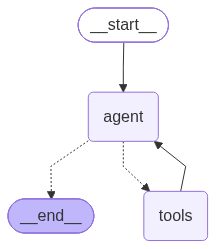

In [110]:
# Visualize the graph
app

# Step 10: Execute the graph

In [111]:
# Define a function to execute the graph and stream outputs from each step
def execute_graph(user_input: str) -> None:
    """
    Stream outputs from the graph execution

    Args:
        user_input (str): User query string
    """
    # Stream outputs from each step in the graph
    for step in app.stream(
        {"messages": [{"role": "user", "content": user_input}]},
        # Stream full value of the state after each step
        stream_mode="values",
    ):
        # Print the latest message from the step
        step["messages"][-1].pretty_print()

In [112]:
# Test the graph execution to view end-to-end flow
execute_graph("I want to go to Barcelona. What's the cheapest nonstop flight there, and the cheapest place to stay for 2 people?")

================================ Human Message =================================

I want to go to Barcelona. What's the cheapest nonstop flight there, and the cheapest place to stay for 2 people?
================================== Ai Message ==================================

Let me start by exploring the database to find the relevant collections and data!
Tool Calls:
  mongodb_list_collections (toolu_bdrk_01HbqjSyDJpAFY5EycPvkkBf)
 Call ID: toolu_bdrk_01HbqjSyDJpAFY5EycPvkkBf
  Args:
================================= Tool Message =================================

flights, listings
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (toolu_bdrk_01LHnC1GUCDpw4K5SdANR3z6)
 Call ID: toolu_bdrk_01LHnC1GUCDpw4K5SdANR3z6
  Args:
    collection_names: flights, listings
================================= Tool Message =================================

Database name: mongodb_genai_devday_agents
Collection name: flights
Schema from a sam

In [113]:
# Ask a follow up question
execute_graph("What did I just ask you?")

================================ Human Message =================================

What did I just ask you?
================================== Ai Message ==================================

You just asked me "What did I just ask you?" — that's the first and only message you've sent me in this conversation. There are no previous questions or interactions before that in our current session.

Is there something I can help you with? I can assist you with querying travel-related data, such as flights or accommodations, or help you make bookings!


# Step 11: Add short-term memory to the agent

In [114]:
from langgraph.checkpoint.mongodb import MongoDBSaver

In [115]:
# Initialize a MongoDB checkpointer
checkpointer = MongoDBSaver(mongodb_client)

In [116]:
# Instantiate the graph with the checkpointer
app = graph.compile(checkpointer=checkpointer)

📚 https://docs.langchain.com/oss/python/langgraph/persistence#threads

In [117]:
# Update the graph execution function to handle thread IDs
def execute_graph(thread_id: str, user_input: str) -> None:
    """
    Stream outputs from the graph execution

    Args:
        thread_id (str): Thread ID for the checkpointer
        user_input (str): User query string
    """
    # Create a runtime config for the thread ID `thread_id`
    config = {"configurable": {"thread_id": thread_id}}
    # Stream outputs from each step in the graph
    for step in app.stream(
        {"messages": [{"role": "user", "content": user_input}]},
        # Pass the config as an additional parameter
        config,
        stream_mode="values",
    ):
        # Print the latest message from the step
        step["messages"][-1].pretty_print()

In [ ]:
# Test graph execution with thread ID
execute_graph(
    "1",
    "I want to go to Barcelona. What's the cheapest nonstop flight there, and the cheapest place to stay for 2 people?",
)

================================ Human Message =================================

I want to go to Barcelona. What's the cheapest nonstop flight there, and the cheapest place to stay for 2 people?
================================== Ai Message ==================================

Let me start by exploring the database to find the relevant collections and data!
Tool Calls:
  mongodb_list_collections (toolu_bdrk_013uHqGiDWJwQVzQbM3hc8JV)
 Call ID: toolu_bdrk_013uHqGiDWJwQVzQbM3hc8JV
  Args:
================================= Tool Message =================================

flights, listings
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (toolu_bdrk_01YRPc2TgtnLKqQFZw99aYPz)
 Call ID: toolu_bdrk_01YRPc2TgtnLKqQFZw99aYPz
  Args:
    collection_names: flights, listings
================================= Tool Message =================================

Database name: mongodb_genai_devday_agents
Collection name: flights
Schema from a sam

In [ ]:
# Follow-up question to ensure message history works
# Notice it uses the flight and accommodation information from the previous question.
execute_graph(
    "1",
    "Book the flight and accommodation for 3 nights under the name Jane Doe.",
)

================================ Human Message =================================

Book the flight and accommodation for 3 nights under the name Jane Doe.
================================== Ai Message ==================================

I'll book both the flight and accommodation for Jane Doe at the same time!
Tool Calls:
  create_booking (toolu_bdrk_015EWzUhQT3snuHHg2HVey49)
 Call ID: toolu_bdrk_015EWzUhQT3snuHHg2HVey49
  Args:
    booking_type: flight
    traveler_name: Jane Doe
    destination: Barcelona
    item_name: TA303
    price_usd: 115.48
  create_booking (toolu_bdrk_01VZHhvBGc2s5NABE4jE1RKg)
 Call ID: toolu_bdrk_01VZHhvBGc2s5NABE4jE1RKg
  Args:
    booking_type: accommodation
    traveler_name: Jane Doe
    destination: Barcelona
    item_name: DOUBLE ROOM for 1 or 2 ppl
    price_usd: 45.0
    travelers: 2
================================= Tool Message =================================

Booked accommodation to Barcelona: DOUBLE ROOM for 1 or 2 ppl, Total price $45.00 for 2 

# 🦹‍♀️ Step 12: Add long-term memory to the agent

📚 https://docs.langchain.com/oss/python/langgraph/add-memory#use-semantic-search

In [161]:
from langgraph.store.mongodb import MongoDBStore, create_vector_index_config
from langchain_voyageai import VoyageAIEmbeddings
import uuid

In [169]:
# Initialize MongoDB collection for long-term memory storage
memory_collection = mongodb_client[DB_NAME]["memories"]

In [170]:
# Initialize the MongoDB long-term memory store with Voyage embeddings to retrieve memories using vector search
mongodb_store = MongoDBStore(
    collection=memory_collection,
    index_config=create_vector_index_config(
        embed=VoyageAIEmbeddings(model="voyage-4"),
        dims=1024,
    ),
)

In [171]:
# Create a tool to save memories to the MongoDB store
@tool
def save_memory(memory: str) -> str:
    """
    Save important facts and preferences about the user for future conversations.

    Args:
    memory: The information to remember
    """
    mongodb_store.put(
        # Namespace for the memory entry. You can also have sub-namespaces to store different types of memories, eg: ("user_1", "preferences")
        # Has to be a tuple, even if it contains empty values
        ("user_1",),
        # Unique memory ID
        key=str(uuid.uuid4()),
        # Content of the memory. Needs to be a dictionary.
        value={"text": memory},
    )
    return f"Memory saved: {memory}"

In [219]:
MEMORY_PROMPT = """
Whenever the user states a preference, constraint, or fact about themselves, such as budget, party size, accommodation type etc, call `save_memory` to record it to long-term memory.
Save one fact/preference per memory entry. Do not save the same fact/preference multiple times.
Use past user preferences to personalize future conversations.
Past user memories:\n{memories}
"""

In [220]:
# Update the tools list to include the `save_memory` tool
# tools.append(save_memory)
# tools_map = {t.name: t for t in tools}
# Bind tools to the LLM
bind_tools = llm.bind_tools(tools)
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT + MEMORY_PROMPT),
        MessagesPlaceholder(variable_name="messages")
    ]
)
# Pre-fill `top_k` and `tool_names` in the prompt template
prompt = prompt.partial(top_k=5, tool_names=", ".join([tool.name for tool in tools]))
llm_with_tools = prompt | bind_tools

In [221]:
# Update the agent node to retrieve relevant long-term memories when responding
def agent_node(state: GraphState) -> Dict[str, List]:
    """
    Agent node

    Args:
        state (GraphState): Graph state

    Returns:
        Dict[str, List]: Updates to messages
    """
    # Get `messages` from the graph `state`
    messages = state["messages"]
    # Search for relevant long-term memories using the user's last message
    memories = mongodb_store.search(("user_1",), query=messages[-1].content, limit=10)
    # Format retrieved memories into a string.
    memories = "\n".join(f"- {m.value['text']}" for m in memories) or "No memories yet."
    # Invoke the tool-augmented LLM with the system prompt and messages as input
    result = llm_with_tools.invoke(
        {
            "memories": memories,
            "messages": messages,
        }
    )
    # Write the `result` to the `messages` attribute of the graph state
    return {"messages": [result]}

In [222]:
# Rebuild the agent graph
graph = StateGraph(GraphState)
graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "agent")
graph.add_edge("tools", "agent")
graph.add_conditional_edges(
    "agent",
    route_tools,
    {"tools": "tools", END: END},
)

In [229]:
# Compile the graph with the MongoDB checkpointer for short-term memory as well as the MongoDB memory store for long-term memory
app = graph.compile(checkpointer=checkpointer, store=mongodb_store)

In [ ]:
# Test creating memories in thread 1 for user user_1
execute_graph(
    "1",
    "I want to go to Barcelona. Can you find me places to stay?"
)

================================ Human Message =================================

I want to go to Barcelona. Can you find me places to stay?
================================== Ai Message ==================================

Let me start by checking the available collections and finding accommodation options in Barcelona for you!
Tool Calls:
  mongodb_list_collections (toolu_bdrk_01LuK2rS9vrNPPo3CFtoXeyR)
 Call ID: toolu_bdrk_01LuK2rS9vrNPPo3CFtoXeyR
  Args:
================================= Tool Message =================================

flights, listings
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (toolu_bdrk_01LQMfkpAisBKTvMk6EsALKC)
 Call ID: toolu_bdrk_01LQMfkpAisBKTvMk6EsALKC
  Args:
    collection_names: listings
================================= Tool Message =================================

Database name: mongodb_genai_devday_agents
Collection name: listings
Schema from a sample of documents from the collection:


In [ ]:
# Test creating memories in thread 1 for user user_1
execute_graph(
    "1",
    "Remember that I only want entire homes and never spend more than $100 a night on stays."
)

================================ Human Message =================================

Remember that I only want entire homes and never spend more than $80 a night on stays.
================================== Ai Message ==================================
Tool Calls:
  save_memory (toolu_bdrk_01VPD5SZVRcqFNZ3DEcpS5p8)
 Call ID: toolu_bdrk_01VPD5SZVRcqFNZ3DEcpS5p8
  Args:
    memory: User only wants entire home/apt listings for accommodation.
  save_memory (toolu_bdrk_0184vt7GbznqeJHUvuHnBmtb)
 Call ID: toolu_bdrk_0184vt7GbznqeJHUvuHnBmtb
  Args:
    memory: User's maximum budget for accommodation is $80 per night.
================================= Tool Message =================================

Memory saved: User's maximum budget for accommodation is $80 per night.
================================== Ai Message ==================================

Got it! I've saved your preferences:
- 🏠 **Entire homes only**
- 💰 **Max $80/night**

I'll make sure to filter by these criteria in all future searc

In [ ]:
# Test creating memories in thread 1 for user user_1
execute_graph(
    "2",
    "I want to go to Barcelona. Can you find me places to stay?"
)

================================ Human Message =================================

I want to go to Barcelona. Can you find me places to stay?
================================== Ai Message ==================================
Tool Calls:
  mongodb_list_collections (toolu_bdrk_01PRKR3HS8H2VxYg9VAxS9iN)
 Call ID: toolu_bdrk_01PRKR3HS8H2VxYg9VAxS9iN
  Args:
================================= Tool Message =================================

flights, listings
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (toolu_bdrk_01CXUnpSi4XyMB9pdEufyRMh)
 Call ID: toolu_bdrk_01CXUnpSi4XyMB9pdEufyRMh
  Args:
    collection_names: listings
================================= Tool Message =================================

Database name: mongodb_genai_devday_agents
Collection name: listings
Schema from a sample of documents from the collection:
_id: String
listing_url: String
name: String
summary: String
space: String
description: String
neighborhood_